# Alpha Entropy Search for New Information-based Bayesian Optimization

- Contributors: fernandezdaniel
- Last updated: Jul 10, 2026
- BoTorch version: v0.18.2

This notebook illustrates how to use **Alpha Entropy Search (AES)** in BoTorch, comparing it
against standard baselines, from:

D. Fernández-Sánchez, E. C. Garrido-Merchán, and D. Hernández-Lobato.
[*Alpha Entropy Search for New Information-based Bayesian Optimization*](https://doi.org/10.1016/j.knosys.2025.113612). Knowledge-Based Systems, 2025.


We introduce a novel information-based class of acquisition functions for Bayesian Optimization called **Alpha Entropy Search (AES)**.
AES is based on the $\alpha$-divergence, which generalizes the KL-divergence. Iteratively, AES selects the next evaluation point as the one whose associated target value has the highest level of dependency with respect to the location and associated value of the global maximum of the optimization problem. Dependency is measured in terms of the $\alpha$-divergence, as an alternative to the KL-divergence. As in the KL-divergence-based case, the resulting acquisition functions favor evaluating the objective function at points that are most informative about the global maximum. However, since the alpha-divergence has a free parameter $\alpha$, it controls the behavior of the divergence by balancing local and global differences. Therefore, different values of $\alpha$ give rise to different acquisition functions.


## Notation

We consider the maximization problem

$$
\mathbf{x}^\star = \arg\max_{\mathbf{x} \in \mathcal{X}} f(\mathbf{x}), \qquad y^\star = f(\mathbf{x}^\star).
$$

At iteration $t$, the observed dataset is $\mathcal{D}_{t-1} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$. BO uses a GP model to define a predictive distribution $p(y \mid \mathcal{D}_{t-1}, \mathbf{x})$.


## Information-Theoretic Acquisition Functions

Information-based BO methods use concepts from information theory to estimate the acquisition function. Concretely, they use the notion of information gain to guide the selection of the next query point to reduce uncertainty about the objective global maximum.

In JES, this is written as

$$
a_{\text{JES}}(\mathbf{x})
= H[p(y\mid\mathcal{D}_{t-1},\mathbf{x})]
- \mathbb{E}_{p(\{\mathbf{x}^\star,y^\star\}\mid\mathcal{D}_{t-1})}
\left[H[p(y\mid\mathcal{D}_{t-1},\mathbf{x},\{\mathbf{x}^\star,y^\star\})]\right].
$$


### Joint Entropy Search (JES)

The JES acquisition function can be interpreted as the mutual information between $\{\mathbf{x}^\star, y^\star\}$ and $y$, which is equal to the KL-divergence between a joint probability distribution and the corresponding factorizing distribution that assumes independence:

$$
\mathrm{KL}\left(
 p(\{\mathbf{x}^\star,y^\star\},y\mid\mathcal{D}_{t-1},\mathbf{x})
 \;\|\;
 p(\{\mathbf{x}^\star,y^\star\}\mid\mathcal{D}_{t-1})p(y\mid\mathcal{D}_{t-1},\mathbf{x})
\right).
$$

Thus, JES chooses the next point $\mathbf{x}$ where there is a higher level of dependency between $y$ and $\{\mathbf{x}^\star,y^\star\}$, as measured by the KL-divergence.


### Alpha Entropy Search (AES)

As an alternative to the KL-divergence, AES estimates the level of dependency between $\{\mathbf{x}^\star, y^\star\}$ and $y$ using the Amari's $\alpha$-divergence. More precisely, we consider a generalization of the KL-divergence to measure how similar $p(\{\mathbf{x}^\star,y^\star\},y)$ is to $p(\{\mathbf{x}^\star, y^\star\})p(y)$, based on the Amari's $\alpha$-divergence.

The Amari's $\alpha$-divergence is obtained by replacing the natural logarithm in the KL-divergence with the $\alpha$-logarithm:

$$
D_{\alpha}(p\|q)
=
\frac{1}{(1-\alpha)\alpha}
\left(1-\int q(z)^{1-\alpha}p(z)^\alpha\,dz\right),
\qquad \alpha\in\mathbb{R}\setminus\{0,1\}.
$$

Amari's divergence is parameterized by $\alpha$, which adjusts the sensitivity to different regions of the probability distributions, allowing us to control the emphasis of the divergence on specific differences between distributions. In most practical applications, values of $\alpha$ in $(0,1)$ are considered, interpolating between reversed ($\alpha \to 0$) and direct ($\alpha \to 1$) KL-divergence limits.

Replacing the KL-divergence in JES with Amari's $\alpha$-divergence gives AES:

$$
a_{\text{AES}}(\mathbf{x})
=
\frac{1}{(1-\alpha)\alpha}
\left(
1
-
\mathbb{E}_{p(\{\mathbf{x}^\star,y^\star\}\mid\mathcal{D}_{t-1})}
\left[
\int p(y\mid\mathcal{D}_{t-1},\mathbf{x})
\left(
\frac{p(y\mid\mathcal{D}_{t-1},\mathbf{x},\{\mathbf{x}^\star,y^\star\})}
{p(y\mid\mathcal{D}_{t-1},\mathbf{x})}
\right)^\alpha
 dy
\right]
\right).
$$

Different values of $\alpha$ result in different acquisition functions.


## Approximating AES

As with other information-based BO methods, the AES expression is analytically intractable and requires approximation.

Specifically, neither the expectation in AES nor the conditional distribution $p(y\mid\mathcal{D}_{t-1},\mathbf{x},\{\mathbf{x}^\star,y^\star\})$ can be computed in closed-form. Therefore, we approximate:

1. the conditional predictive distribution $p(y|\mathcal{D}_{t-1},\mathbf{x},\{\mathbf{x}^\star, y^\star\})$ 
2. the expectation over $p(\{\mathbf{x}^\star, y^\star\}|\mathcal{D}_{t-1})$.


### Approximating the Conditional Distribution and the Expectation

Here, we adopt a similar approach as that of JES to approximate the conditional predictive distribution.

For simplicity, first consider a noiseless evaluation setting, i.e., $y=f(\mathbf{x})$. To approximate $p(f(\mathbf{x})\mid\mathcal{D}_{t-1},\mathbf{x},\{\mathbf{x}^\star,y^\star\})$, we incorporate $(\mathbf{x}^\star,y^\star)$ as extra data and use a truncated Gaussian distribution. In this truncated construction, the support is restricted to $f(\mathbf{x}) < y^\star$. Again, this is only an approximation to the intractable conditional distribution.

In this case, the moments are

$$
m_{\mathrm{tr}}(\mathbf{x}) = m(\mathbf{x}) - \sqrt{v(\mathbf{x})}\frac{\phi(\beta)}{\Phi(\beta)},
$$
$$
v_{\mathrm{tr}}(\mathbf{x}) = v(\mathbf{x})\left[1 - \beta\frac{\phi(\beta)}{\Phi(\beta)} - \left(\frac{\phi(\beta)}{\Phi(\beta)}\right)^2\right],
\quad \beta = \frac{y^\star - m(\mathbf{x})}{\sqrt{v(\mathbf{x})}}.
$$

In the noisy setting, we further approximate the truncated Gaussian with a Gaussian distribution, as in JES, and then add Gaussian observation noise. This results in a Gaussian approximation of the conditional distribution of $y$. That is, $p(y|\mathcal{D}_{t-1},\mathbf{x}, \{\mathbf{x}^\star, y^\star\})\approx \mathcal{N}(y|m_\text{tr}(\mathbf{x}), v_\text{tr}(\mathbf{x}) + \sigma^2)$, where $\sigma^2$ is the variance of the noise.


After approximating the conditional distribution, we evaluate the integral of AES in closed form using the exponential form of the Gaussian distribution:
$$
\int 
    p(y|\mathcal{D}_{t-1}, \mathbf{x})
            \left(
        \frac{p(y|\mathcal{D}_{t-1},\mathbf{x},\{\mathbf{x}^\star, y^\star\})}{p(y|\mathcal{D}_{t-1}, \mathbf{x})}
            \right)^\alpha dy 
= 
\exp\left\{ (\alpha - 1) g(\boldsymbol{\eta}) -\alpha g(\boldsymbol{\eta}^\star)
+ g((1 - \alpha)\boldsymbol{\eta} + \alpha \boldsymbol{\eta}^\star) \right\}\,,
$$ 
where $g(\boldsymbol{\eta})$ is the log-normalizer of a Gaussian with natural parameters $\boldsymbol{\eta}$,
$\boldsymbol{\eta}$ are the natural parameters of $p(y|\mathcal{D}_{t-1}, \mathbf{x})$, and
$\boldsymbol{\eta}^\star$ are the natural parameters of the Gaussian approximation of $p(y|\mathcal{D}_{t-1},\mathbf{x},\{\mathbf{x}^\star, y^\star\})$.

Finally, to approximate the expectation in AES, we generate samples of pairs of optimal locations and optimal values $\{\mathbf{x}^\star, y^\star\}$ from $p(\{\mathbf{x}^\star, y^\star\}|\mathcal{D}_{t-1})$.

## References

[1] C. Hvarfner, F. Hutter, and N. Nardi, [**Joint Entropy Search for Maximally-informed Bayesian Optimization**](https://dl.acm.org/doi/10.5555/3600270.3601105), NeurIPS, 2022.

[2] B. Tu, A. Gandy, N. Kantas, and B. Shafei, [**Joint Entropy Search for Multi-Objective Bayesian Optimization**](https://dl.acm.org/doi/10.5555/3600270.3600991), NeurIPS, 2022.

[3] D. Fernández-Sánchez, E. C. Garrido-Merchán, and D. Hernández-Lobato, [**Alpha Entropy Search for New Information-based Bayesian Optimization**](https://doi.org/10.1016/j.knosys.2025.113612), Knowledge-Based Systems, 2025.


# 1. Single-objective visualization

In [1]:
import os

import numpy as np
import torch
import matplotlib.pyplot as plt

from gpytorch.constraints import GreaterThan
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ZeroMean

from botorch.acquisition.utils import get_optimal_samples
from botorch.models.gp_regression import SingleTaskGP
from botorch.acquisition.joint_entropy_search import qJointEntropySearch

from botorch_community.acquisition.alpha_entropy_search import qAlphaEntropySearch

#warnings.filterwarnings("ignore")

SMOKE_TEST = False #os.environ.get("SMOKE_TEST")
tkwargs = {"dtype": torch.double, "device": "cpu"}

def fit_model_1d_example(train_X, train_Y, likelihood_noise=1e-8):
    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(1e-10))
    likelihood.noise = torch.tensor(likelihood_noise, **tkwargs)
    likelihood.raw_noise.requires_grad_(False)

    model = SingleTaskGP(
        train_X=train_X,
        train_Y=train_Y,
        likelihood=likelihood,
        mean_module=ZeroMean(),
        covar_module=ScaleKernel(RBFKernel(ard_num_dims=train_X.shape[-1])),
        input_transform=None,
        outcome_transform=None,
    )
    model.covar_module.outputscale = 1.0
    model.covar_module.base_kernel.lengthscale = 2.0
    model.covar_module.raw_outputscale.requires_grad_(False)
    model.covar_module.base_kernel.raw_lengthscale.requires_grad_(False)
    return model.eval()

seed = 1
alphas = [0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999]

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


We reproduce the one-dimensional example from [3] (Figure comparing AES for different values of
$\alpha$, JES, and the ensemble acquisition function). We fit a `SingleTaskGP` on three noiseless
observations over $\mathcal{X} = [-5, 5]$, with a zero mean, a squared-exponential kernel of
lengthscale $2.0$ and outputscale $1.0$, and a fixed observation noise variance of $10^{-8}$. All
hyperparameters are fixed in the initialization rather than estimated via the marginal
log-likelihood, since this lets us show the differences between methods more clearly in this
single one-dimensional example. This produces a figure qualitatively similar to the one in the
paper.


In [2]:
torch.manual_seed(seed)
np.random.seed(seed)

train_X = torch.tensor([[1.0], [1.7], [2.3]], **tkwargs) #, dtype=torch.float64) #
train_Y = torch.tensor([[-0.3], [0.07], [0.1]], **tkwargs) #, dtype=torch.float64) #
bounds = torch.tensor([[-5.0], [5.0]], **tkwargs) #, dtype=torch.float64) #

model = fit_model_1d_example(train_X=train_X, train_Y=train_Y, likelihood_noise=1e-8)

We evaluate the posterior mean and variance on a dense grid over $[-5, 5]$, and sample 32 pairs $\{\mathbf{x}^\star, y^\star\}$ from the posterior using `get_optimal_samples`, which draws a posterior sample path via a random features (Matheron) approximation and optimizes it with L-BFGS to obtain its argmax.

In [3]:
X = torch.linspace(bounds[0, 0], bounds[1, 0], 1000, **tkwargs).unsqueeze(-1) #.unsqueeze(-1)
mean_fX = model.posterior(X).mean.squeeze(-1).detach().numpy()
std_fX = model.posterior(X).variance.sqrt().squeeze(-1).detach().numpy()
x_np = X.squeeze(-1).detach().numpy()

upper = mean_fX + std_fX
lower = mean_fX - std_fX

In [4]:
num_samples = 32
optimal_inputs, optimal_outputs = get_optimal_samples(model, bounds=bounds, num_optima=num_samples)
x_opt, y_opt = optimal_inputs, optimal_outputs

Using those sampled optima, we evaluate JES and AES acquisitions on the dense grid (with `condition_noiseless=False`), normalize each curve by its maximum, and build the normalized AES ensemble.


In [5]:
jes_lb = qJointEntropySearch(
    model=model,
    optimal_inputs=optimal_inputs,
    optimal_outputs=optimal_outputs,
    estimation_type="LB",
    condition_noiseless=False,
)

aes_lb = {
    alpha: qAlphaEntropySearch(
        model=model,
        optimal_inputs=optimal_inputs,
        optimal_outputs=optimal_outputs,
        estimation_type="LB",
        condition_noiseless=False,
        alpha=alpha,
    )
    for alpha in alphas
}

# the acquisition function call takes a three-dimensional tensor
fwd_X = X.unsqueeze(-2)

# make the acquisition functions live on the same scale
scale_acqvals = True

jes_X = jes_lb(fwd_X).detach().numpy()
if scale_acqvals:
    jes_X = jes_X / jes_X.max()

results = {"JES": jes_X}
ensemble_X = np.zeros_like(jes_X)

for alpha in alphas:
    aes_X = aes_lb[alpha](fwd_X).detach().numpy()
    if scale_acqvals:
        aes_X = aes_X / aes_X.max()
    results[f"AES_{alpha}"] = aes_X
    ensemble_X = ensemble_X + aes_X / len(alphas)

if scale_acqvals:
    ensemble_X = ensemble_X / ensemble_X.max()
results["Ensemble"] = ensemble_X


Finally, we count the number of local maxima of each acquisition function and locate its global maximizer, then plot the GP posterior, the acquisition functions, and each method's global maximizer.

JES: 12 local maxima, argmax at x=-5.000
AES_0.001: 6 local maxima, argmax at x=2.057
AES_0.1: 4 local maxima, argmax at x=2.057
AES_0.2: 4 local maxima, argmax at x=2.057
AES_0.3: 4 local maxima, argmax at x=2.057
AES_0.4: 4 local maxima, argmax at x=2.057
AES_0.5: 4 local maxima, argmax at x=-5.000
AES_0.6: 7 local maxima, argmax at x=-5.000
AES_0.7: 9 local maxima, argmax at x=-5.000
AES_0.8: 12 local maxima, argmax at x=-5.000
AES_0.9: 12 local maxima, argmax at x=-5.000
AES_0.999: 12 local maxima, argmax at x=-5.000
Ensemble: 9 local maxima, argmax at x=-5.000


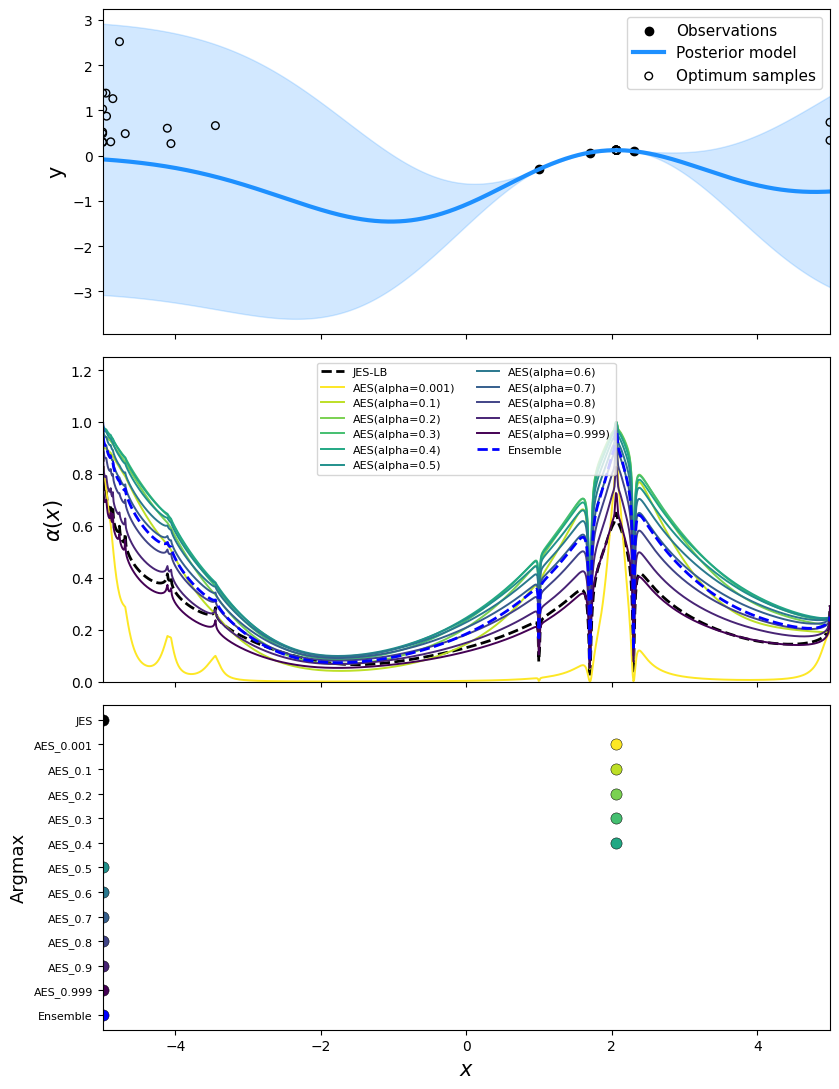

In [6]:
x_acq = X.squeeze(-1).detach().numpy()
method_order = ["JES"] + [f"AES_{alpha}" for alpha in alphas] + ["Ensemble"]

local_maxima = {}
argmax_x = {}
for name in method_order:
    y = np.asarray(results[name]).reshape(-1)
    local_maxima[name] = int(np.sum(np.diff(np.sign(np.diff(y))) == -2)) if y.size >= 3 else 0
    argmax_x[name] = float(x_acq[int(np.argmax(y))])

for name in method_order:
    print(f"{name}: {local_maxima[name]} local maxima, argmax at x={argmax_x[name]:.3f}")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8.5, 11), sharex=True)

ax1.scatter(train_X, train_Y, color="k", label="Observations")
ax1.plot(x_np, mean_fX, color="dodgerblue", linewidth=3, label="Posterior model")
ax1.fill_between(x_np, mean_fX + 3 * std_fX, mean_fX - 3 * std_fX, alpha=0.2, color="dodgerblue")
ax1.scatter(x_opt, y_opt, facecolors="none", edgecolors="k", s=30, label="Optimum samples")
ax1.set_ylabel("y", fontsize=15)
ax1.legend(fontsize=11, loc="best")

aes_colors = plt.cm.viridis(np.linspace(1, 0, len(alphas)))
method_colors = {"JES": "black", "Ensemble": "blue"}
for i, alpha in enumerate(alphas):
    method_colors[f"AES_{alpha}"] = aes_colors[i]

ax2.plot(x_acq, results["JES"], color="black", linestyle="--", linewidth=2, label="JES-LB")
for i, alpha in enumerate(alphas):
    name = f"AES_{alpha}"
    ax2.plot(x_acq, results[name], color=aes_colors[i], linewidth=1.4, label=f"AES(alpha={alpha})")
ax2.plot(x_acq, results["Ensemble"], color="blue", linestyle="--", linewidth=2, label="Ensemble")
ax2.set_ylabel(r"$\alpha(x)$", fontsize=15)
ax2.set_ylim(0.0, 1.25)
ax2.legend(loc="upper center", ncol=2, fontsize=8)

y_rows = np.arange(len(method_order))
for y_row, name in enumerate(method_order):
    ax3.scatter(argmax_x[name], y_row, color=method_colors[name], s=65, edgecolors="k", linewidth=0.35)

ax3.set_yticks(y_rows)
ax3.set_yticklabels(method_order, fontsize=8)
ax3.invert_yaxis()
ax3.set_xlabel("$x$", fontsize=15)
ax3.set_ylabel("Argmax", fontsize=13)
ax3.set_xlim(x_acq.min(), x_acq.max())

plt.tight_layout()
plt.show()

# 2. Benchmark comparison on Hartmann-3D

We now compare `EI`, `MES`, `JES`, and `AES` (with $\alpha = \{0.1, 0.3, 0.5, 0.7\}$) in closed-loop BO
on the noiseless 3-dimensional **Hartmann** function, following a protocol similar to the one described in
[3] Section "Benchmark Experiments":

- A `SingleTaskGP` with a Matérn 5/2 ARD kernel, fit by maximizing the marginal log-likelihood.
  As in the paper's noiseless benchmark experiments, the likelihood noise is fixed to a small
  value ($10^{-4}$).
- $S=32$ samples of $\{\mathbf{x}^\star, y^\star\}$ per iteration, obtained via a random features
  (Matheron path) approximation of the posterior.
- Acquisition functions are optimized with L-BFGS-B using 1 restart and 200 candidate points.
- 10 randomly chosen initial observations.
- The recommendation at each iteration is simply the best observation made so far.
- We use 10 seeds per method recommendation.

The metric is the **natural log relative regret**, $\log(y^\star - f(\mathbf{x}_{\text{rec}}))$,
between the objective at the recommendation and the known global optimum, averaged over 10
random seeds (fewer than the 100 repetitions and 300 iterations used in the paper)

Note: this is not a bit-for-bit reproduction of the paper's figure.

In [7]:
import os
import warnings

from botorch.acquisition.analytic import ExpectedImprovement
from botorch.acquisition.joint_entropy_search import qJointEntropySearch
from botorch.acquisition.max_value_entropy_search import qMaxValueEntropy
from botorch.acquisition.utils import get_optimal_samples
from botorch.exceptions.errors import ModelFittingError
from botorch.fit import fit_gpytorch_mll
from botorch.models.gp_regression import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.optim import optimize_acqf
from botorch.test_functions.synthetic import Hartmann
from botorch.utils.transforms import unnormalize
from gpytorch.mlls import ExactMarginalLogLikelihood

warnings.filterwarnings("ignore")
tkwargs = {"dtype": torch.double, "device": "cpu"}

SMOKE_TEST = False #os.environ.get("SMOKE_TEST")
NUM_RESTARTS_OPT = 1
RAW_SAMPLES_OPT_ACQ = 200


def compute_median_distance(inputs):
    pairwise_dists = torch.cdist(inputs, inputs, p=2)
    rows, cols = torch.triu_indices(pairwise_dists.shape[0], pairwise_dists.shape[0], offset=1)
    return pairwise_dists[rows, cols].median()

def fit_model(train_X, train_Y, state_dict=None, likelihood_noise=1e-4, exp_noiseless=True):
    r"""Fits a Matern-5/2 ARD `SingleTaskGP` with a fixed small noise level (1e-4), as in the
    paper's noiseless benchmark experiments. Falls back to a median-heuristic
    lengthscale initialization if the default initialization fails to fit.
    """

    if exp_noiseless:
        model = SingleTaskGP(train_X, train_Y, outcome_transform=Standardize(m=1))
        model.likelihood.noise = likelihood_noise
        model.likelihood.noise_covar.raw_noise.requires_grad_(False)
    
    else:
        model = SingleTaskGP(train_X, train_Y, outcome_transform=Standardize(m=1))
    
    # We use the previously trained model, if available
    
    if state_dict is not None:
        model.load_state_dict(state_dict)
    
    try:
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
    except ModelFittingError:
        model.covar_module.base_kernel.lengthscale = compute_median_distance(train_X)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
    
    return model

In [8]:
class HartmannProblem:
    r"""Noiseless 3-dimensional Hartmann problem on the unit cube, to be maximized."""

    def __init__(self, seed):
        state = torch.random.get_rng_state()
        torch.manual_seed(seed)
        self.problem = Hartmann(dim=3, negate=True).to(**tkwargs)
        self.bounds = self.problem.bounds
        self.y_opt = self.problem.optimal_value
        torch.random.set_rng_state(state)

    def __call__(self, X):
        return self.problem(unnormalize(X, bounds=self.bounds))[:, None]

In [9]:
acq_configs = [
    ["EI"],
    ["MES"],
    ["JES"],
    ["AES_0.1", 0.1],
    ["AES_0.3", 0.3],
    ["AES_0.5", 0.5],
    ["AES_0.7", 0.7],
]

num_seeds = 1 if SMOKE_TEST else 10
n_init = 10
n_bo_iters = 10 if SMOKE_TEST else 100
num_optima_samples = 4 if SMOKE_TEST else 32
use_checkpoints = False

Seed 1/10
  - Running EI
  - Running MES
  - Running JES
  - Running AES_0.1
  - Running AES_0.3
  - Running AES_0.5
  - Running AES_0.7
Seed 2/10
  - Running EI
  - Running MES
  - Running JES
  - Running AES_0.1
  - Running AES_0.3
  - Running AES_0.5
  - Running AES_0.7
Seed 3/10
  - Running EI
  - Running MES
  - Running JES
  - Running AES_0.1
  - Running AES_0.3
  - Running AES_0.5
  - Running AES_0.7
Seed 4/10
  - Running EI
  - Running MES
  - Running JES
  - Running AES_0.1
  - Running AES_0.3
  - Running AES_0.5
  - Running AES_0.7
Seed 5/10
  - Running EI
  - Running MES
  - Running JES
  - Running AES_0.1
  - Running AES_0.3
  - Running AES_0.5
  - Running AES_0.7
Seed 6/10
  - Running EI
  - Running MES
  - Running JES
  - Running AES_0.1
  - Running AES_0.3
  - Running AES_0.5
  - Running AES_0.7
Seed 7/10
  - Running EI
  - Running MES
  - Running JES
  - Running AES_0.1
  - Running AES_0.3
  - Running AES_0.5
  - Running AES_0.7
Seed 8/10
  - Running EI
  - Running MES


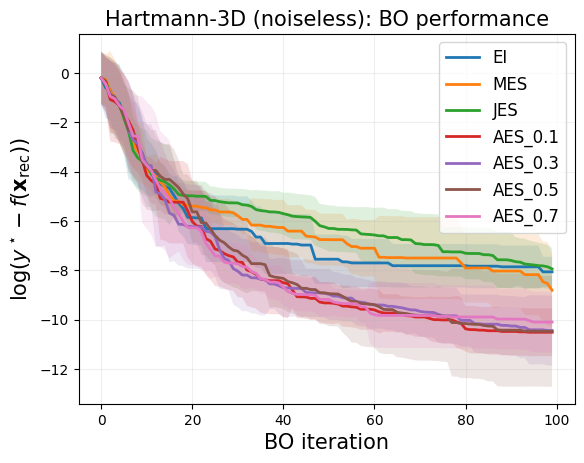

In [10]:
bounds = torch.tensor([[0.0, 0.0, 0.0], [1.0, 1.0, 1.0]], **tkwargs)

# If we activate the use of checkpoints, each (acquisition, seed)
# combination is checkpointed to its own file, so that a run that is
# interrupted (e.g. a restarted kernel) can be resumed instead of
# started over from scratch.
CHECKPOINT_DIR = "hartmann3d_checkpoints"
if use_checkpoints:
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def checkpoint_path(acq_name, seed):
    return os.path.join(CHECKPOINT_DIR, f"{acq_name}_seed{seed}.pt")

ckpt_path = None
results_hartmann3 = {config[0]: [] for config in acq_configs}

for seed in range(num_seeds):
    problem = HartmannProblem(seed=seed)

    print(f"Seed {seed + 1}/{num_seeds}")
    for acq_config in acq_configs:
        acq_name, alpha = acq_config[0], (acq_config[1] if len(acq_config) > 1 else None)
        if use_checkpoints:
            ckpt_path = checkpoint_path(acq_name, seed)

        # We reset the RNG
        torch.manual_seed(seed)
        np.random.seed(seed)

        if use_checkpoints and os.path.exists(ckpt_path):
            checkpoint = torch.load(ckpt_path, weights_only=True)
            train_X, train_Y = checkpoint["train_X"], checkpoint["train_Y"]
            log_gaps = checkpoint["log_gaps"]
            print(f"  - Resuming {acq_name} from iteration {len(log_gaps)}/{n_bo_iters}")
        else:
            train_X = torch.rand(n_init, bounds.shape[-1], **tkwargs)
            train_Y = problem(train_X)
            log_gaps = []
            print(f"  - Running {acq_name}")

        for _ in range(len(log_gaps), n_bo_iters):
            model = fit_model(train_X, train_Y.detach())

            if acq_name == "EI":
                acqf = ExpectedImprovement(model=model, best_f=train_Y.max())
            elif acq_name == "MES":
                candidate_set = torch.rand(1000, bounds.shape[-1], **tkwargs)
                acqf = qMaxValueEntropy(model, candidate_set)
            else:
                optimal_inputs, optimal_outputs = get_optimal_samples(
                    model, bounds=bounds, num_optima=num_optima_samples
                )
                if acq_name == "JES":
                    acqf = qJointEntropySearch(
                        model=model,
                        optimal_inputs=optimal_inputs,
                        optimal_outputs=optimal_outputs,
                        estimation_type="LB",
                    )
                elif acq_name.startswith("AES"):
                    acqf = qAlphaEntropySearch(
                        model=model,
                        optimal_inputs=optimal_inputs,
                        optimal_outputs=optimal_outputs,
                        alpha=alpha,
                    )

            candidate, _ = optimize_acqf(
                acq_function=acqf,
                bounds=bounds,
                q=1,
                num_restarts=NUM_RESTARTS_OPT,
                raw_samples=RAW_SAMPLES_OPT_ACQ,
            )

            # In the noiseless setting, the recommendation is the best observation made so far
            # (following Section 'Experiments' of the paper).
            obj_at_recommendation = train_Y.max().item()
            log_gaps.append(float(np.log(max(problem.y_opt - obj_at_recommendation, 1e-12))))

            new_Y = problem(candidate)
            train_X = torch.cat([train_X, candidate.detach()], dim=0)
            train_Y = torch.cat([train_Y, new_Y], dim=0)

            if use_checkpoints:
                torch.save(
                    {"train_X": train_X, "train_Y": train_Y, "log_gaps": log_gaps}, ckpt_path
                )

        results_hartmann3[acq_name].append(log_gaps)

results_hartmann3 = {k: torch.tensor(v, **tkwargs) for k, v in results_hartmann3.items()}

iters = np.arange(n_bo_iters)
for acq_config in acq_configs:
    acq_name = acq_config[0]
    values = results_hartmann3[acq_name]
    mean = values.mean(dim=0).cpu().numpy()
    std = values.std(dim=0).cpu().numpy() if values.shape[0] > 1 else np.zeros_like(mean)
    plt.plot(iters, mean, linewidth=2, label=acq_name)
    plt.fill_between(iters, mean - std, mean + std, alpha=0.15)

plt.xlabel("BO iteration", fontsize=15)
plt.ylabel("Log. Rel. Diff. w.r.t Max", fontsize=15)
plt.title("Hartmann-3D (noiseless)", fontsize=15)
plt.legend(fontsize=12, loc="best")
plt.grid(alpha=0.2)
plt.show()

The first experiment visualizes how the AES acquisition function changes with $\alpha$, compared
against JES and the ensemble of AES acquisitions across $\alpha$ values. The second experiment
compares closed-loop BO performance on the noiseless Hartmann-3D problem against `EI`, `MES`, and
`JES`.

Both experiments follow the paper [3] as closely as practical within a single notebook: the
first reproduces the paper's 1D local-maxima figure directly; the second follows the same GP
setup and optimization protocol as the paper's Hartmann-3D benchmark, but with fewer seeds and
iterations so that it runs in a reasonable amount of time. As such, the second experiment should
be read as a qualitative illustration of AES's competitiveness with EI, MES, and JES rather than
an exact reproduction of the paper's benchmark figure.
